# 05 — Comparação das Três Abordagens do IPB (produção)

Comparação das três versões do Índice de Potencial Bancário **lendo direto do BigQuery**
(tabelas `analytics_ipb_*` publicadas por `scripts/07_publica_ipb_bigquery.py`):

| Versão | Tabela | Conceito |
|---|---|---|
| **V1 — IPB Clássico** | `analytics_ipb_v1_classico` | Fórmula original, 5 pilares com pesos iguais |
| **V2 — IPB Recalibrado** | `analytics_ipb_v2_recalibrado` | Pesos diferenciados + `tensao_digital_bancaria` |
| **V3 — IPB Presença Bancária Completa** | `analytics_ipb_v3_presenca_completa` | Correspondentes por tipo + turismo suave (ex-Abordagem 2) |

Origem da comparação: diagnóstico do viês para cidades ricas na EDA do alpha
→ `docs/Plano_Recalibracao_IPB.md` → V2 → Gap Analysis → V3.
Figuras salvas em `docs/assets/figures/` (prefixo `05_`) e citadas no `docs/Relatorio_EDA.md`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

from src.config import (
    TABLE_ANALYTICS_IPB_COMPARACAO,
    TABLE_ANALYTICS_IPB_V1,
    TABLE_ANALYTICS_IPB_V2,
    TABLE_ANALYTICS_IPB_V3,
    TABLE_TRUSTED_MUNICIPIOS,
)
from src.utils.bigquery import read_table_to_dataframe

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 110

# Resolve a raiz do repo independentemente do diretório de execução
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = Path("../..").resolve()
FIGURES = ROOT / "docs" / "assets" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# Leituras do BigQuery (camada analytics + trusted p/ análise de estrato)
comp = read_table_to_dataframe(TABLE_ANALYTICS_IPB_COMPARACAO)
v1 = read_table_to_dataframe(TABLE_ANALYTICS_IPB_V1)
v2 = read_table_to_dataframe(TABLE_ANALYTICS_IPB_V2)
v3 = read_table_to_dataframe(TABLE_ANALYTICS_IPB_V3)
trusted = read_table_to_dataframe(TABLE_TRUSTED_MUNICIPIOS)

for df in (comp, v1, v2, v3):
    df["id_municipio"] = df["id_municipio"].astype(str).str.zfill(7)
trusted["id_municipio"] = trusted["id_municipio"].astype(str).str.zfill(7)

comp = comp.merge(
    trusted[["id_municipio", "populacao_total"]], on="id_municipio", how="left"
)

COLS_IPB = ["ipb_v1_classico", "ipb_v2_recalibrado", "ipb_v3_presenca_completa"]
COLS_RANK = ["rank_v1", "rank_v2", "rank_v3"]

print(f"comparacao: {len(comp)} municípios | população nula: {comp['populacao_total'].isna().sum()}")

comparacao: 5570 municípios | população nula: 0


## 1. Estatísticas gerais

In [2]:
stats = comp[COLS_IPB].describe().T[["mean", "50%", "min", "max"]].round(2)
stats.columns = ["média", "mediana", "mínimo", "máximo"]
stats

,média,mediana,mínimo,máximo
ipb_v1_classico,35.85,35.86,0.0,82.54
ipb_v2_recalibrado,40.85,40.65,0.0,83.85
ipb_v3_presenca_completa,25.63,25.23,0.0,61.38


## 2. Distribuição dos IPBs

Quanto mais à direita (e dispersa), mais o índice separa municípios. A V3 tem
média menor e cauda mais curta: o redesenho do pilar D comprime as pontuações
de cidades ricas já bancarizadas.

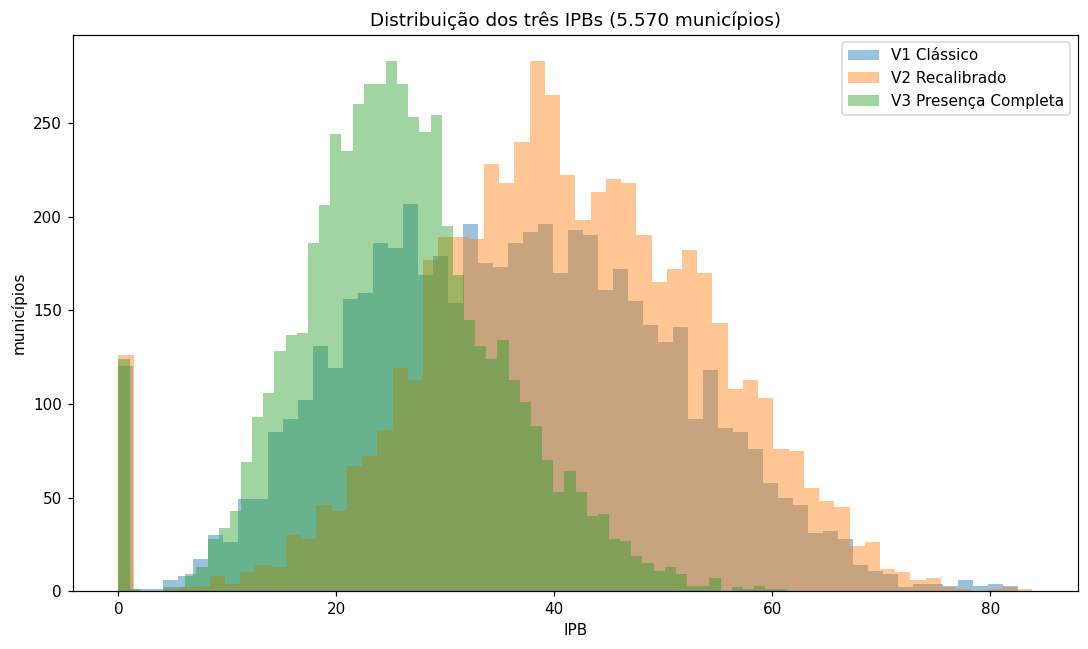

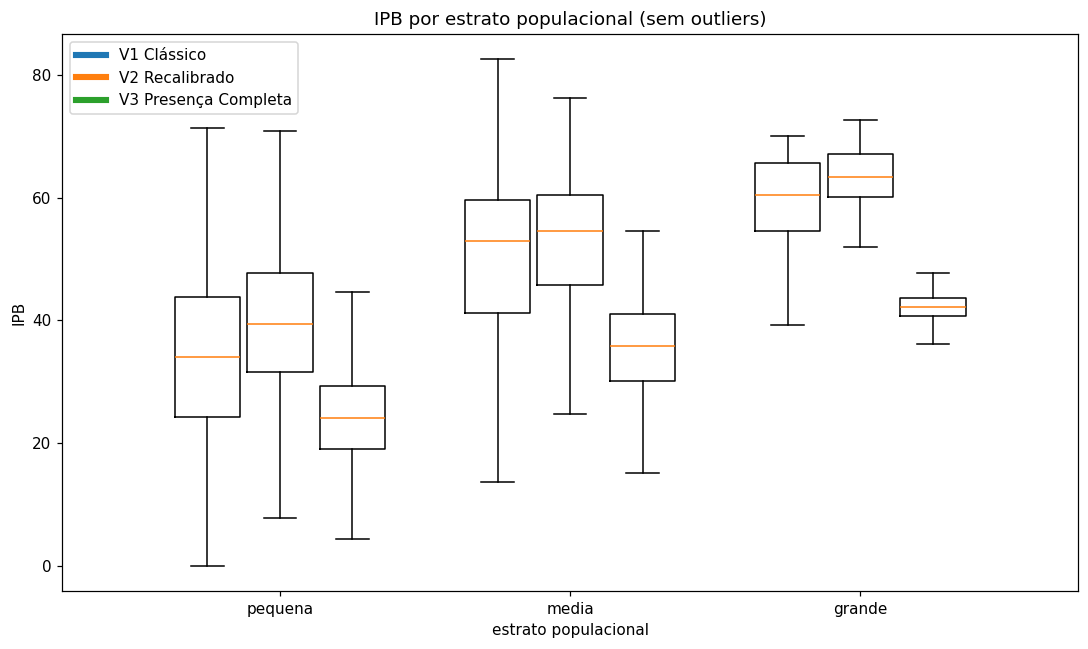

In [3]:
fig, ax = plt.subplots()
for col, rotulo in zip(COLS_IPB, ["V1 Clássico", "V2 Recalibrado", "V3 Presença Completa"]):
    ax.hist(comp[col], bins=60, alpha=0.45, label=rotulo)
ax.set_xlabel("IPB")
ax.set_ylabel("municípios")
ax.set_title("Distribuição dos três IPBs (5.570 municípios)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "05_dist_ipb_tres_versoes.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots()
ordem = ["pequena", "media", "grande"]
dados = [comp.groupby("estrato_populacional")[col].apply(list) for col in COLS_IPB]
posicoes = np.arange(len(ordem))
largura = 0.25
for i, (col, rotulo) in enumerate(zip(COLS_IPB, ["V1", "V2", "V3"])):
    caixas = [dados[i].get(e, []) for e in ordem]
    ax.boxplot(caixas, positions=posicoes + (i - 1) * largura, widths=largura * 0.9, showfliers=False)
for i, rotulo in enumerate(["V1", "V2", "V3"]):
    ax.text(i * 0.05, 102, "")
ax.set_xticks(posicoes)
ax.set_xticklabels(ordem)
ax.set_xlabel("estrato populacional")
ax.set_ylabel("IPB")
ax.set_title("IPB por estrato populacional (sem outliers)")
handles = [plt.Line2D([0], [0], color=f"C{i}", lw=4) for i in range(3)]
ax.legend(handles, ["V1 Clássico", "V2 Recalibrado", "V3 Presença Completa"], loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES / "05_boxplot_ipb_estrato.png", bbox_inches="tight")
plt.show()

## 3. Correlação entre os rankings (Spearman)

Quanto da ordenação se preserva entre versões? Correlação alta V1×V2 (mesma
estrutura, só pesos) e menor V1×V3 (redesenho do pilar D) indica que a V3 de
fato reordena o ranking — não é um ajuste cosmético.

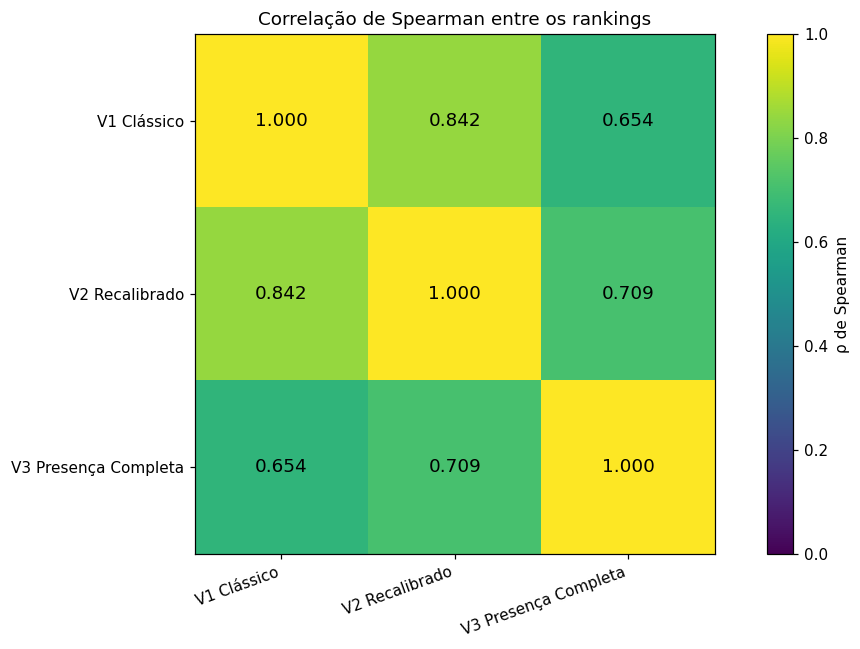

V1×V3: ρ=0.654 (p=0.0e+00)


In [4]:
matriz = np.zeros((3, 3))
pvals = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        rho, p = spearmanr(comp[COLS_RANK[i]], comp[COLS_RANK[j]])
        matriz[i, j] = rho
        pvals[i, j] = p

fig, ax = plt.subplots()
im = ax.imshow(matriz, vmin=0, vmax=1, cmap="viridis")
rotulos = ["V1 Clássico", "V2 Recalibrado", "V3 Presença Completa"]
ax.set_xticks(range(3)); ax.set_xticklabels(rotulos, rotation=20, ha="right")
ax.set_yticks(range(3)); ax.set_yticklabels(rotulos)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{matriz[i, j]:.3f}", ha="center", va="center",
                color="white" if matriz[i, j] < 0.6 else "black", fontsize=12)
fig.colorbar(im, ax=ax, label="ρ de Spearman")
ax.set_title("Correlação de Spearman entre os rankings")
fig.tight_layout()
fig.savefig(FIGURES / "05_correlacao_spearman_ranks.png", bbox_inches="tight")
plt.show()
print(f"V1×V3: ρ={matriz[0,2]:.3f} (p={pvals[0,2]:.1e})")

## 4. Movimentação no ranking (V1 × V3)

Cada ponto é um município. O quadrante superior-esquerdo concentra as
oportunidades que a V3 revela e a V1 (riqueza pura) escondia; o inferior-
direito, cidades ricas já bancarizadas que caem.

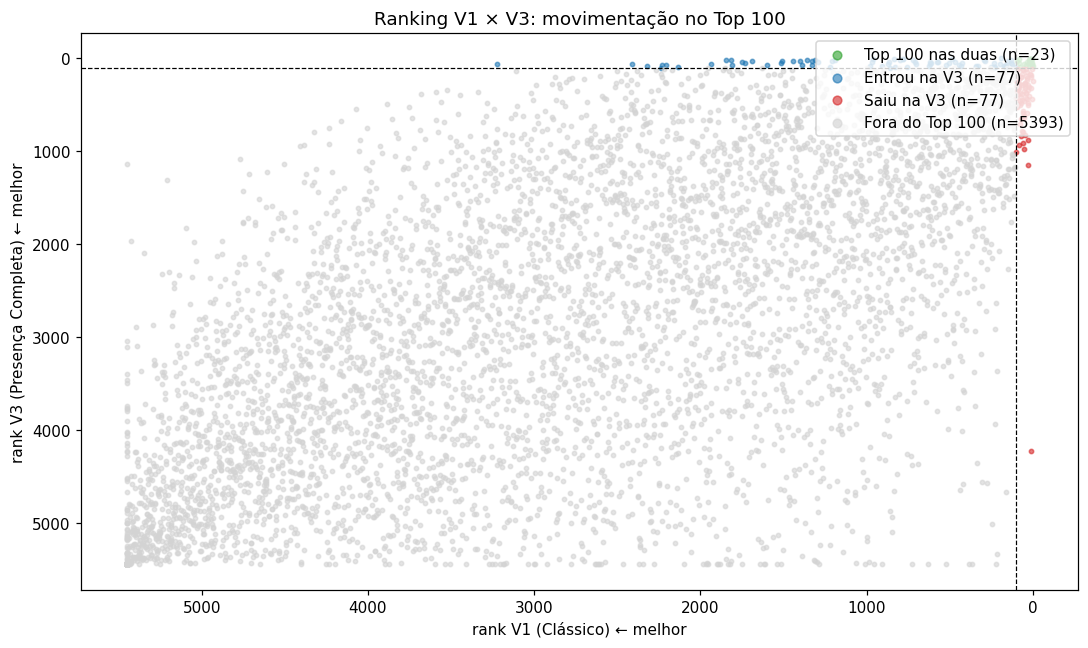

,cenario,sairam,entraram
0,V1 -> V2,40,40
1,V2 -> V3,74,74
2,V1 -> V3,77,77


In [5]:
top100_v1 = set(comp.nsmallest(100, "rank_v1")["id_municipio"])
top100_v3 = set(comp.nsmallest(100, "rank_v3")["id_municipio"])

def classe(row):
    if row["id_municipio"] in top100_v1 and row["id_municipio"] in top100_v3:
        return "Top 100 nas duas"
    if row["id_municipio"] in top100_v3:
        return "Entrou na V3"
    if row["id_municipio"] in top100_v1:
        return "Saiu na V3"
    return "Fora do Top 100"

comp["classe_top100"] = comp.apply(classe, axis=1)

cores = {"Top 100 nas duas": "C2", "Entrou na V3": "C0", "Saiu na V3": "C3", "Fora do Top 100": "lightgray"}
fig, ax = plt.subplots()
for nome, cor in cores.items():
    sub = comp[comp["classe_top100"] == nome]
    ax.scatter(sub["rank_v1"], sub["rank_v3"], s=8, c=cor, label=f"{nome} (n={len(sub)})", alpha=0.6)
ax.axvline(100, color="k", ls="--", lw=0.8)
ax.axhline(100, color="k", ls="--", lw=0.8)
ax.invert_xaxis(); ax.invert_yaxis()
ax.set_xlabel("rank V1 (Clássico) ← melhor")
ax.set_ylabel("rank V3 (Presença Completa) ← melhor")
ax.set_title("Ranking V1 × V3: movimentação no Top 100")
ax.legend(markerscale=2, loc="upper right")
fig.tight_layout()
fig.savefig(FIGURES / "05_scatter_rank_v1_v3.png", bbox_inches="tight")
plt.show()

movimentacao = pd.DataFrame({
    "cenario": ["V1 -> V2", "V2 -> V3", "V1 -> V3"],
    "sairam": [
        len(top100_v1 - set(comp.nsmallest(100, "rank_v2")["id_municipio"])),
        len(set(comp.nsmallest(100, "rank_v2")["id_municipio"]) - top100_v3),
        len(top100_v1 - top100_v3),
    ],
})
movimentacao["entraram"] = movimentacao["sairam"]
movimentacao

## 5. Distribuição regional do Top 100 por versão

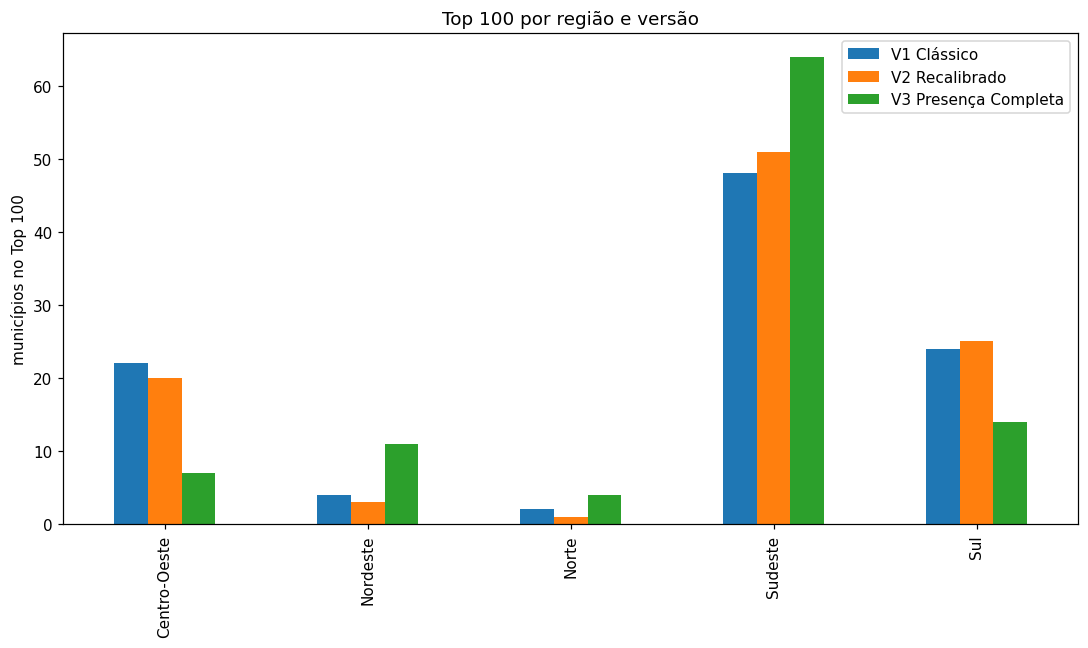

In [6]:
regioes = sorted(comp["nome_regiao"].unique())
contagens = pd.DataFrame({
    "regiao": regioes,
    "V1 Clássico": [int((comp["nome_regiao"] == r).mul(comp["rank_v1"] <= 100).sum()) for r in regioes],
    "V2 Recalibrado": [int((comp["nome_regiao"] == r).mul(comp["rank_v2"] <= 100).sum()) for r in regioes],
    "V3 Presença Completa": [int((comp["nome_regiao"] == r).mul(comp["rank_v3"] <= 100).sum()) for r in regioes],
}).set_index("regiao")
contagens

fig, ax = plt.subplots()
contagens.plot(kind="bar", ax=ax)
ax.set_ylabel("municípios no Top 100")
ax.set_xlabel("")
ax.set_title("Top 100 por região e versão")
ax.legend(title=None)
fig.tight_layout()
fig.savefig(FIGURES / "05_top100_regional.png", bbox_inches="tight")
plt.show()

## 6. Perfil médio do Top 100 por versão

Médias dos scores de pilar (A consumo, B dinamismo digital, C infra, D gap,
E perfil) entre os Top 100 de cada versão. A V3 troca capacidade de consumo
(A) por gap bancário (D): o Top 100 deixa de ser um retrato de riqueza.

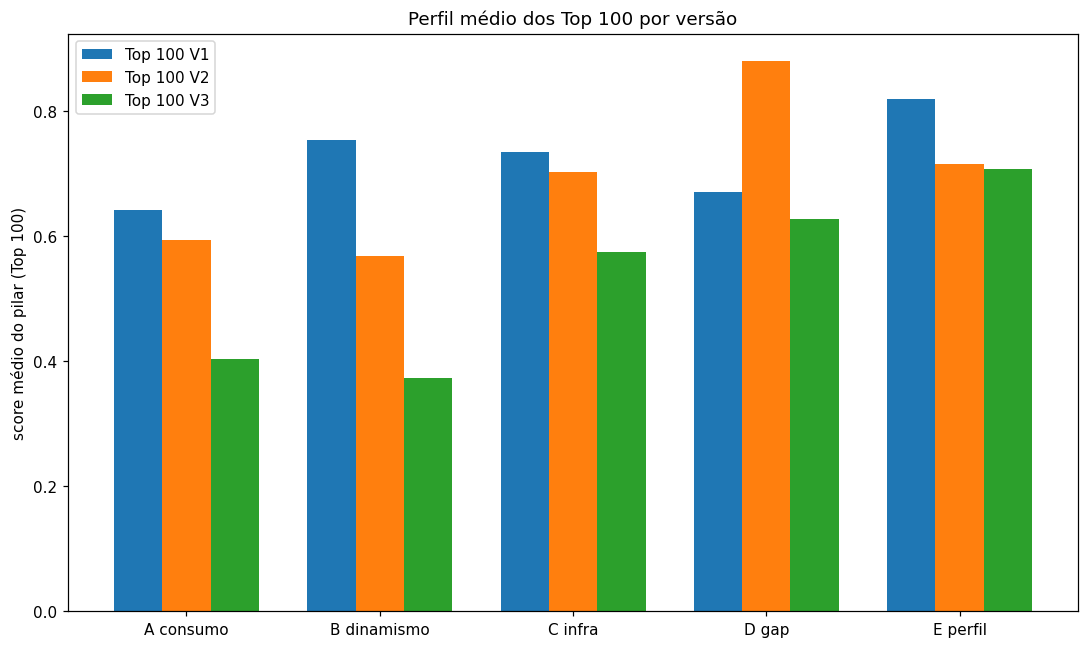

,V1,V2,V3
pilar,,,
a,0.641,0.594,0.404
b,0.754,0.569,0.373
c,0.735,0.703,0.575
d,0.670,0.880,0.628
e,0.820,0.715,0.707


In [7]:
pilares = {}
for nome, df, rank_col in [("V1", v1, "rank"), ("V2", v2, "rank"), ("V3", v3, "rank")]:
    top = df.nsmallest(100, rank_col)
    pilares[nome] = [top[f"score_{p}"].mean() for p in "abcde"]
perfil = pd.DataFrame(pilares, index=list("abcde"))
perfil.index.name = "pilar"

fig, ax = plt.subplots()
x = np.arange(5)
largura = 0.25
for i, nome in enumerate(["V1", "V2", "V3"]):
    ax.bar(x + (i - 1) * largura, perfil[nome], largura, label=f"Top 100 {nome}")
ax.set_xticks(x); ax.set_xticklabels(["A consumo", "B dinamismo", "C infra", "D gap", "E perfil"])
ax.set_ylabel("score médio do pilar (Top 100)")
ax.set_title("Perfil médio dos Top 100 por versão")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "05_perfis_top100.png", bbox_inches="tight")
plt.show()
perfil.round(3)

## 7. Alerta turismo na V3

`score_turismo` ∈ [0, 1] (0.5·Pix≥p90 + 0.3·PIB≤mediana + 0.2·cidade pequena)
aplica desconto de 0–15% no pilar B. Verificamos se cidades turísticas típicas
continuam no topo apesar do desconto — mitigação, não eliminação.

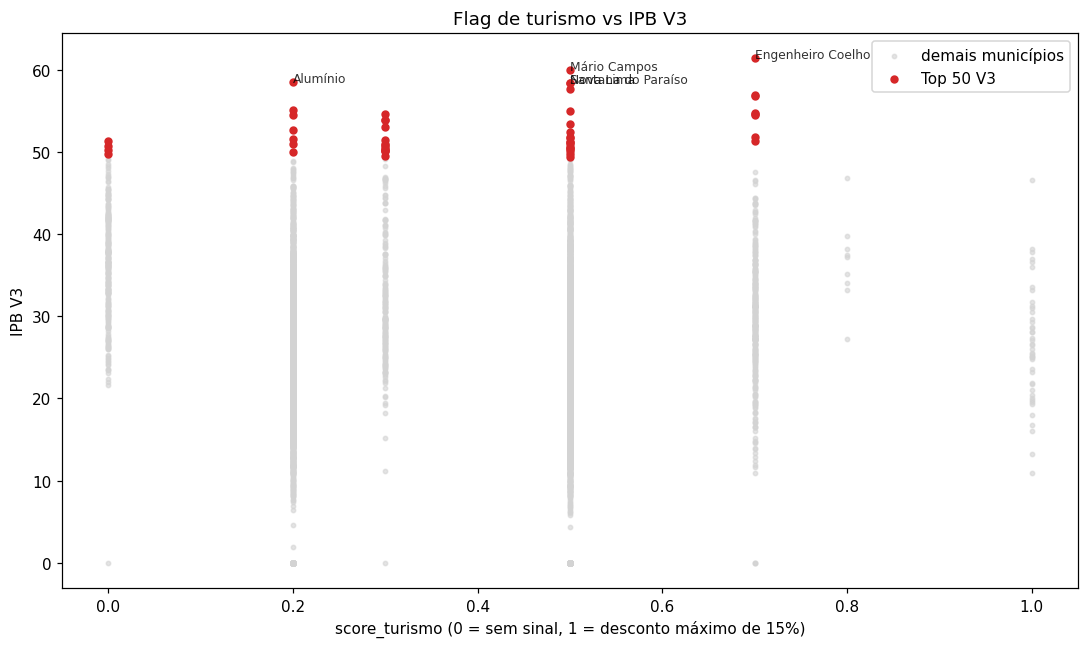

In [8]:
top10_v3 = v3.nsmallest(10, "rank")[
    ["rank", "nome_municipio", "sigla_uf", "estrato_populacional", "ipb", "score_turismo"]
].reset_index(drop=True)
top10_v3

fig, ax = plt.subplots()
ax.scatter(v3["score_turismo"], v3["ipb"], s=8, c="lightgray", alpha=0.6, label="demais municípios")
destaque = v3.nsmallest(50, "rank")
ax.scatter(destaque["score_turismo"], destaque["ipb"], s=20, c="C3", label="Top 50 V3")
for _, r in v3.nsmallest(5, "rank").iterrows():
    ax.annotate(r["nome_municipio"], (r["score_turismo"], r["ipb"]), fontsize=8, alpha=0.8)
ax.set_xlabel("score_turismo (0 = sem sinal, 1 = desconto máximo de 15%)")
ax.set_ylabel("IPB V3")
ax.set_title("Flag de turismo vs IPB V3")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "05_score_turismo_rank.png", bbox_inches="tight")
plt.show()

## 8. Sensibilidade da classificação por estrato

A classificação oficial (pequena <50k, média 50–500k, grande >500k) é decisão
do projeto e concentra ~88% dos municípios em "pequena". Testamos uma
alternativa de **tercis populacionais** (`pd.qcut`). Como o estrato só afeta a
posição **dentro** do grupo (`rank_estrato`), a sensibilidade correta compara:
(a) a posição relativa de cada município no grupo oficial vs no seu tercil, e
(b) o overlap dos Top 20 de cada grupo — não o Top 100 geral, que independe da
classificação.

Distribuição de municípios (oficial × tercil):
tercil                T1 (menor)    T2  T3 (maior)
estrato_populacional                              
grande                         0     0          41
media                          0     0         616
pequena                     1857  1856        1200
Spearman(posição no estrato oficial × posição no tercil): ρ=0.890 (p=0.0e+00)
Share 'pequena' na classificação oficial: 88.2%

Overlap do Top 20 oficial com o Top 20 dos tercis:
tercil             T1 tercil  T2 tercil  T3 tercil
grupo_oficial                                     
grande (oficial)           0          0          0
media (oficial)            0          0         11
pequena (oficial)          4          7          9


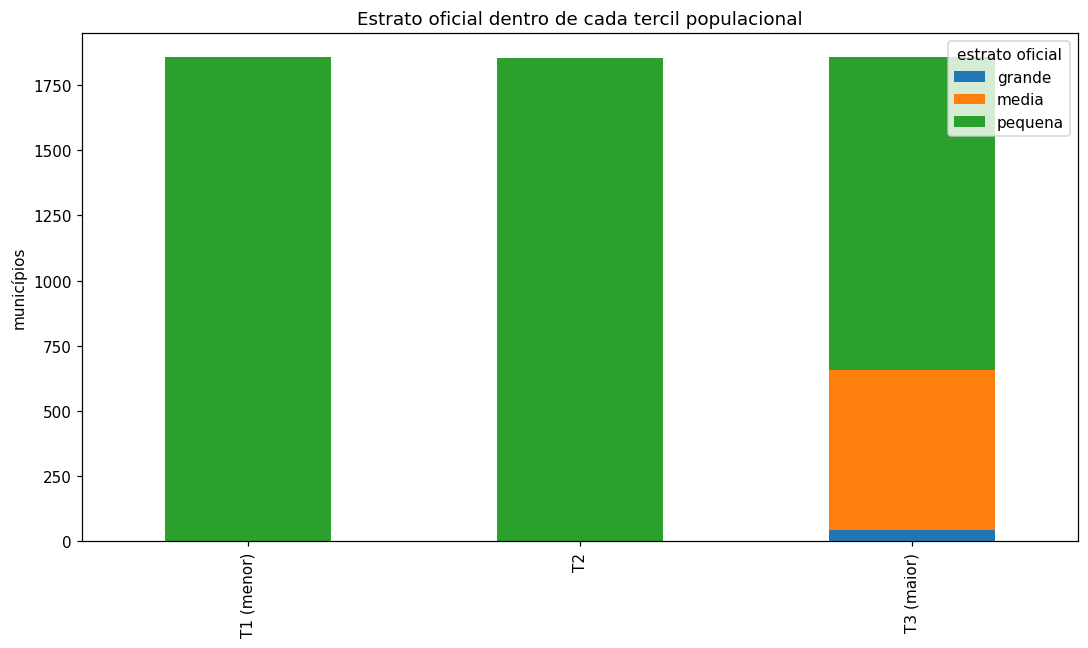

In [9]:
comp["tercil"] = pd.qcut(comp["populacao_total"], 3, labels=["T1 (menor)", "T2", "T3 (maior)"])

# Distribuição oficial vs tercis
dist = pd.crosstab(comp["estrato_populacional"], comp["tercil"])
print("Distribuição de municípios (oficial × tercil):")
print(dist)

# Rank V3 DENTRO de cada tercil (análogo ao rank_estrato oficial)
comp["rank_v3_tercil"] = comp.groupby("tercil", observed=True)["ipb_v3_presenca_completa"].rank(
    ascending=False, method="min"
).astype(int)

# O estrato só afeta a posição DENTRO do grupo (rank_estrato). A sensibilidade
# correta compara a posição relativa do município no seu grupo oficial vs no
# seu tercil — não o Top 100 geral (que independe da classificação).
rho, p = spearmanr(comp["rank_v3_estrato"], comp["rank_v3_tercil"])
print(f"Spearman(posição no estrato oficial × posição no tercil): ρ={rho:.3f} (p={p:.1e})")
pct_pequena = (comp["estrato_populacional"] == "pequena").mean()
print(f"Share 'pequena' na classificação oficial: {pct_pequena:.1%}")

# Impacto no produto: Top 20 de cada grupo — oficial vs tercil
linhas = []
for nome, mascara in [
    ("pequena (oficial)", comp["estrato_populacional"] == "pequena"),
    ("media (oficial)", comp["estrato_populacional"] == "media"),
    ("grande (oficial)", comp["estrato_populacional"] == "grande"),
    ("T1 tercil", comp["tercil"] == "T1 (menor)"),
    ("T2 tercil", comp["tercil"] == "T2"),
    ("T3 tercil", comp["tercil"] == "T3 (maior)"),
]:
    sub = comp[mascara]
    col_rank = "rank_v3_estrato" if "oficial" in nome else "rank_v3_tercil"
    top20 = set(sub.nsmallest(20, col_rank)["id_municipio"])
    linhas.append({"grupo": nome, "n_municipios": len(sub), "top20": top20})
overlap = pd.DataFrame([{
    "grupo_oficial": l1["grupo"], "tercil": l2["grupo"],
    "overlap_top20": len(l1["top20"] & l2["top20"]),
} for l1 in linhas[:3] for l2 in linhas[3:]])
print("\nOverlap do Top 20 oficial com o Top 20 dos tercis:")
print(overlap.pivot(index="grupo_oficial", columns="tercil", values="overlap_top20"))

fig, ax = plt.subplots()
contagens_tercil = comp.groupby("tercil", observed=True)["estrato_populacional"].value_counts().unstack()
contagens_tercil.plot(kind="bar", stacked=True, ax=ax)
ax.set_ylabel("municípios")
ax.set_xlabel("")
ax.set_title("Estrato oficial dentro de cada tercil populacional")
ax.legend(title="estrato oficial")
fig.tight_layout()
fig.savefig(FIGURES / "05_sensibilidade_estrato.png", bbox_inches="tight")
plt.show()

## 9. Síntese para o relatório

1. **V1 → V2**: mesmo ranking em essência (Spearman alto), com correção de pesos.
2. **V2 → V3**: reordenação profunda (Spearman moderado) — o redesenho do pilar D com correspondentes muda quem são as oportunidades.
3. **Top 100 regional**: V3 dilui Sul/Centro-Oeste e sobe Nordeste/Norte (ver seção 5).
4. **Turismo**: flag mitiga mas não elimina cidades de evento especial (seção 7).
5. **Estrato**: resultado da sensibilidade acima — registrar no Relatório EDA junto com a origem da classificação (decisão do projeto, Relatório EDA 5.1).

Próximos passos fora deste notebook: validação de negócio dos Top 100 da V3,
cobertura 4G/5G (pilar C) e modelo residual (Abordagem 3/ML).